In [35]:
# %% [markdown]
# # Preprocessing MSI and Visium data for GNN
# 
# This notebook:
# - Loads MSI and Visium h5ad files
# - Normalizes intensity / counts
# - Computes spatial coordinates
# - Builds a radius-based neighbor graph
# - Performs neighbor-count diagnostics and radius-sweep plots
# - Saves PyG `.pt` Data objects ready for GNN

# %% [markdown]
# ## 1. Imports and configuration

# %%
import os
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
from scipy.spatial import cKDTree
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import torch
from torch_geometric.data import Data
from tqdm import tqdm
import matplotlib.pyplot as plt

# %% [markdown]
# ## 2. User configuration

# %%
# Paths
MSI_INPUT_FOLDER = "/home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered_halfbrain_common/"
MSI_SAMPLE_FILES = [
    "halfbrain_yc_1_filtered_common.h5ad",
    "halfbrain_yc_2_filtered_common.h5ad",
    "halfbrain_yc_3_filtered_common.h5ad",
    "halfbrain_yc_4_filtered_common.h5ad",
    "halfbrain_yad_1_filtered_common.h5ad",
    "halfbrain_yad_2_filtered_common.h5ad",
    "halfbrain_yad_3_filtered_common.h5ad",
    "halfbrain_yad_4_filtered_common.h5ad",
    "halfbrain_ac_1_filtered_common.h5ad",
    "halfbrain_ac_2_filtered_common.h5ad",
    "halfbrain_ac_3_filtered_common.h5ad",
    "halfbrain_ac_4_filtered_common.h5ad",
    "halfbrain_aad_1_filtered_common.h5ad",
    "halfbrain_aad_2_filtered_common.h5ad",
    "halfbrain_aad_3_filtered_common.h5ad",
    "halfbrain_aad_4_filtered_common.h5ad"
]
MSI_SAMPLE_IDS = [
    "YC_1","YC_2","YC_3","YC_4",
    "YAD_1","YAD_2","YAD_3","YAD_4",
    "AC_1","AC_2","AC_3","AC_4",
    "AAD_1","AAD_2","AAD_3","AAD_4"
]

RNA_INPUT_FOLDER = "/home/ajarrah/PhD_Thesis/chapter_4/h5ad_data/gene_top_800/"
RNA_TISSUE_POSITIONS_CSV = "/home/ajarrah/PhD_Thesis/chapter_4/tissue_positions/tissue_positions.csv"
RNA_SAMPLE_FILES = [
    "YC_1.h5ad","YC_2.h5ad","YC_3.h5ad","YC_4.h5ad",
    "YAD_1.h5ad","YAD_2.h5ad","YAD_3.h5ad","YAD_4.h5ad",
    "AC_1.h5ad","AC_2.h5ad","AC_3.h5ad","AC_4.h5ad",
    "AAD_1.h5ad","AAD_2.h5ad","AAD_3.h5ad","AAD_4.h5ad"
]
RNA_SAMPLE_IDS = [
    "YC_1","YC_2","YC_3","YC_4",
    "YAD_1","YAD_2","YAD_3","YAD_4",
    "AC_1","AC_2","AC_3","AC_4",
    "AAD_1","AAD_2","AAD_3","AAD_4"
]

OUTPUT_DIR = "processed_graphs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Parameters
RADIUS_UM = 110.0
REDUCE_DIM = True
N_COMPONENTS = 128
LOG_TRANSFORM = True
VISIUM_HVG_N = 2000
MSI_TOP_K_MZ = None


In [36]:

# %% [markdown]
# ## 3. Helper functions

# %%
def ensure_numpy_matrix(X):
    if sparse.issparse(X):
        return X.toarray()
    return np.asarray(X)

def tic_normalize(intensity_matrix, tic_values):
    tic = np.array(tic_values, dtype=float)
    tic[tic == 0] = 1.0
    return intensity_matrix / tic[:, None]

def build_radius_edges(coords, radius):
    tree = cKDTree(coords)
    neighbors = tree.query_ball_point(coords, r=radius)
    row_idx, col_idx = [], []
    for i, nbrs in enumerate(neighbors):
        for j in nbrs:
            if i == j: continue
            row_idx.append(i)
            col_idx.append(j)
    edge_index = torch.tensor([row_idx, col_idx], dtype=torch.long)
    return edge_index

def reduce_features(X, n_components=N_COMPONENTS):
    scaler = StandardScaler(with_mean=False)
    Xs = scaler.fit_transform(X)
    svd = TruncatedSVD(n_components=min(n_components, Xs.shape[1]-1 or 1), random_state=0)
    return svd.fit_transform(Xs).astype(np.float32)

def diagnostic_neighbor_count(coords_um, radius_um, sample_id):
    tree = cKDTree(coords_um)
    neighbors = tree.query_ball_point(coords_um, r=radius_um)
    counts = np.array([len(n)-1 for n in neighbors])
    print(f"\n=== Neighbor Diagnostic for {sample_id} ===")
    print(f"Radius = {radius_um} µm")
    print(f"N nodes = {len(coords_um)}")
    print(f"Mean neighbors:   {counts.mean():.2f}")
    print(f"Median neighbors: {np.median(counts):.2f}")
    print(f"Isolated nodes:   {(counts==0).sum()} ({(counts==0).mean()*100:.2f}%)")
    return counts

def radius_sweep_diagnostic(coords_um, sample_id, radius_list=None):
    if radius_list is None:
        radius_list = np.linspace(20, 300, 15)
    
    mean_neighbors = []
    median_neighbors = []
    isolated_fraction = []

    for r in radius_list:
        tree = cKDTree(coords_um)
        neighbors = tree.query_ball_point(coords_um, r=r)
        counts = np.array([len(n)-1 for n in neighbors])
        mean_neighbors.append(counts.mean())
        median_neighbors.append(np.median(counts))
        isolated_fraction.append((counts==0).mean())

    plt.figure(figsize=(6,4))
    plt.plot(radius_list, mean_neighbors, marker='o', label='Mean neighbors')
    plt.plot(radius_list, median_neighbors, marker='s', label='Median neighbors')
    plt.plot(radius_list, np.array(isolated_fraction)*100, marker='^', label='Isolated nodes (%)')
    plt.xlabel('Radius (µm)')
    plt.ylabel('Neighbors / Isolated %')
    plt.title(f'Neighbor counts vs radius ({sample_id})')
    plt.grid(True)
    plt.legend()
    plt.show()
    
    return radius_list, mean_neighbors, median_neighbors, isolated_fraction


In [37]:

# %% [markdown]
# ## 4. MSI processing

# %%
def process_msi_h5ad(path_h5ad, sample_id,
                     radius_um=RADIUS_UM,
                     log_transform=LOG_TRANSFORM,
                     reduce_dim=REDUCE_DIM,
                     top_k_mz=MSI_TOP_K_MZ):
    adata = sc.read_h5ad(path_h5ad)
    X_raw = ensure_numpy_matrix(adata.X)
    coords = np.vstack([adata.obs["x_um"].values, adata.obs["y_um"].values]).T.astype(float)
    tic = adata.obs.get("Processed_TIC", adata.obs.get("TIC", X_raw.sum(axis=1)))
    X_norm = tic_normalize(X_raw.astype(float), tic)
    if top_k_mz:
        mean_by_mz = X_norm.mean(axis=0)
        idxs = np.argsort(mean_by_mz)[::-1][:top_k_mz]
        X_sel = X_norm[:, idxs]
    else:
        X_sel = X_norm
    if log_transform: X_sel = np.log1p(X_sel)
    X_sel = np.nan_to_num(X_sel, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    if reduce_dim and X_sel.shape[1] > N_COMPONENTS:
        X_proc = reduce_features(X_sel)
    else:
        X_proc = X_sel.astype(np.float32)
    edge_index = build_radius_edges(coords, radius_um)
    diagnostic_neighbor_count(coords, radius_um, sample_id)
    radius_sweep_diagnostic(coords, sample_id)
    data = Data(x=torch.tensor(X_proc, dtype=torch.float),
                pos=torch.tensor(coords, dtype=torch.float),
                edge_index=edge_index)
    data.sample_id = sample_id
    data.modality = "MSI"
    return data


In [38]:
# %% [markdown]
# ## 5. Visium processing

# %%
def reconstruct_visium_coords_from_tissue_positions(tissue_positions_csv, spot_spacing_um=100.0):
    df = pd.read_csv(tissue_positions_csv, usecols=["barcode", "array_row", "array_col"])

    # Vectorized coordinate calculation
    df["y_um"] = df["array_row"] * (np.sqrt(3)/2 * spot_spacing_um)
    df["x_um"] = df["array_col"] * (spot_spacing_um / 2)

    # Round to 2 decimal places
    df["x_um"] = df["x_um"].round(2)
    df["y_um"] = df["y_um"].round(2)

    # Return only x/y with barcode as index
    return df.set_index("barcode")[["x_um", "y_um"]]


def process_visium_h5ad(path_h5ad, sample_id, tissue_positions_df,
                        radius_um=RADIUS_UM,
                        log_transform=LOG_TRANSFORM,
                        reduce_dim=REDUCE_DIM):
    """
    Process Visium h5ad file that already has reduced genes.
    """
    adata = sc.read_h5ad(path_h5ad)
    
    # Normalize and log1p if requested
    sc.pp.normalize_total(adata, target_sum=1e4)
    if log_transform:
        sc.pp.log1p(adata)
    
    # Get gene expression matrix
    X_sel = ensure_numpy_matrix(adata.X).astype(np.float32)
    
    # Get coordinates for each spot
    coords = np.array([
        tissue_positions_df.loc[bc, ["x_um","y_um"]].values
        if bc in tissue_positions_df.index else (np.nan, np.nan)
        for bc in adata.obs_names
    ])
    
    # Keep only spots with valid coordinates
    valid_mask = ~np.isnan(coords).any(axis=1)
    coords_valid = coords[valid_mask]
    X_valid = X_sel[valid_mask]
    
    # Optional dimensionality reduction
    if reduce_dim and X_valid.shape[1] > N_COMPONENTS:
        X_proc = reduce_features(X_valid)
    else:
        X_proc = X_valid
    
    # Build radius-based edges
    edge_index = build_radius_edges(coords_valid, radius_um)
    
    # Diagnostics (optional)
    diagnostic_neighbor_count(coords_valid, radius_um, sample_id)
    radius_sweep_diagnostic(coords_valid, sample_id)
    
    # Build PyTorch Geometric Data
    data = Data(
        x=torch.tensor(X_proc, dtype=torch.float),
        pos=torch.tensor(coords_valid, dtype=torch.float),
        edge_index=edge_index
    )
    data.sample_id = sample_id
    data.modality = "Visium"
    
    return data




MSI samples:   0%|          | 0/16 [00:00<?, ?it/s]


=== Neighbor Diagnostic for YC_1 ===
Radius = 110.0 µm
N nodes = 6688
Mean neighbors:   7.80
Median neighbors: 8.00
Isolated nodes:   1 (0.01%)


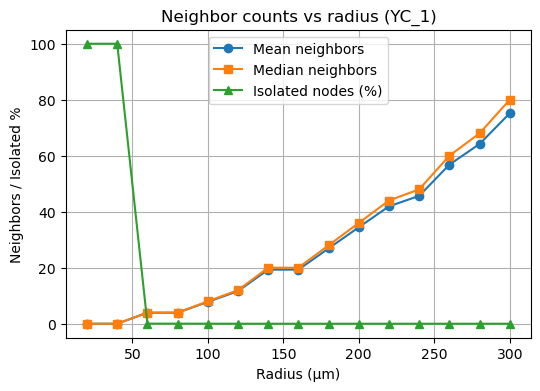

MSI samples:   6%|▋         | 1/16 [00:00<00:10,  1.37it/s]


=== Neighbor Diagnostic for YC_2 ===
Radius = 110.0 µm
N nodes = 7858
Mean neighbors:   7.84
Median neighbors: 8.00
Isolated nodes:   0 (0.00%)


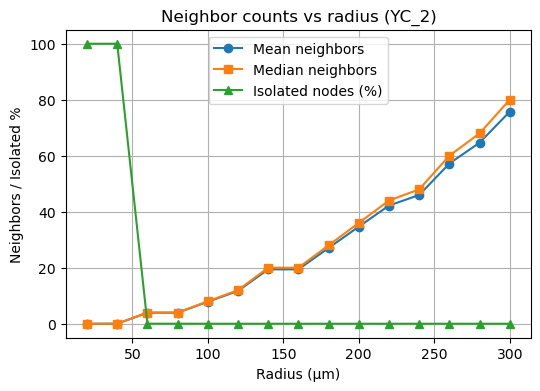

MSI samples:  12%|█▎        | 2/16 [00:01<00:11,  1.25it/s]


=== Neighbor Diagnostic for YC_3 ===
Radius = 110.0 µm
N nodes = 7150
Mean neighbors:   7.82
Median neighbors: 8.00
Isolated nodes:   3 (0.04%)


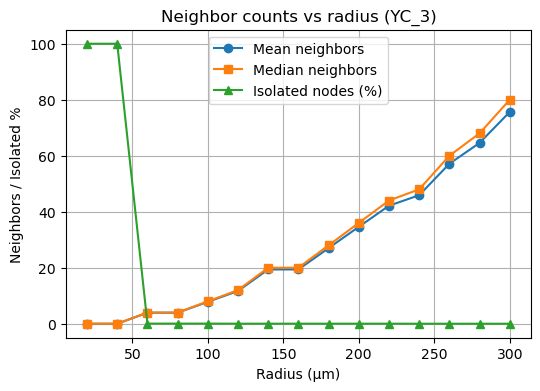

MSI samples:  19%|█▉        | 3/16 [00:02<00:10,  1.25it/s]


=== Neighbor Diagnostic for YC_4 ===
Radius = 110.0 µm
N nodes = 6067
Mean neighbors:   7.73
Median neighbors: 8.00
Isolated nodes:   2 (0.03%)


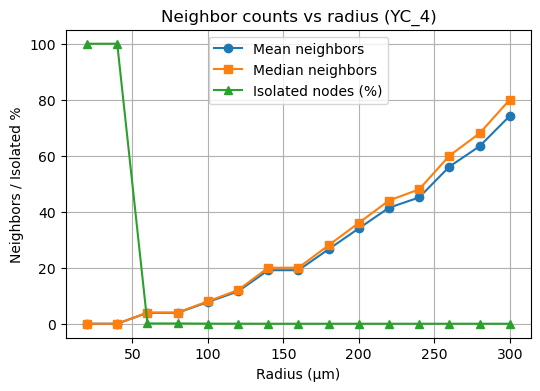

MSI samples:  25%|██▌       | 4/16 [00:03<00:09,  1.33it/s]


=== Neighbor Diagnostic for YAD_1 ===
Radius = 110.0 µm
N nodes = 7517
Mean neighbors:   7.86
Median neighbors: 8.00
Isolated nodes:   0 (0.00%)


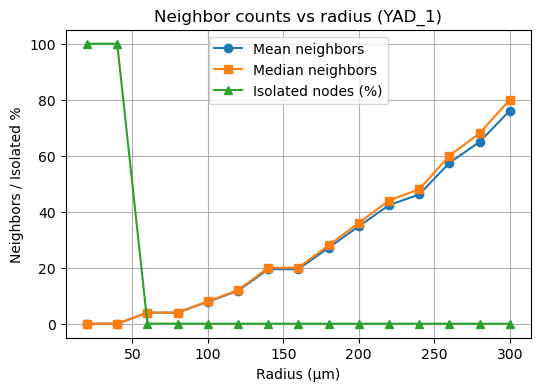

MSI samples:  31%|███▏      | 5/16 [00:04<00:09,  1.18it/s]


=== Neighbor Diagnostic for YAD_2 ===
Radius = 110.0 µm
N nodes = 7596
Mean neighbors:   7.85
Median neighbors: 8.00
Isolated nodes:   0 (0.00%)


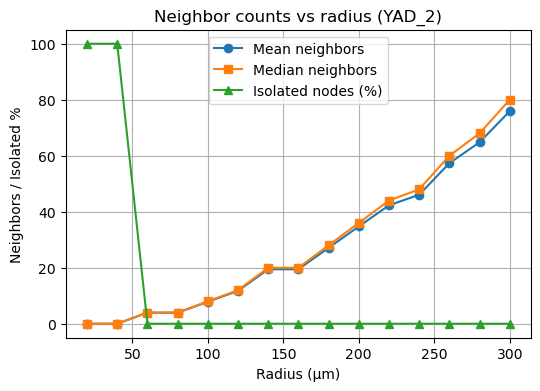

MSI samples:  38%|███▊      | 6/16 [00:04<00:08,  1.19it/s]


=== Neighbor Diagnostic for YAD_3 ===
Radius = 110.0 µm
N nodes = 6844
Mean neighbors:   7.85
Median neighbors: 8.00
Isolated nodes:   0 (0.00%)


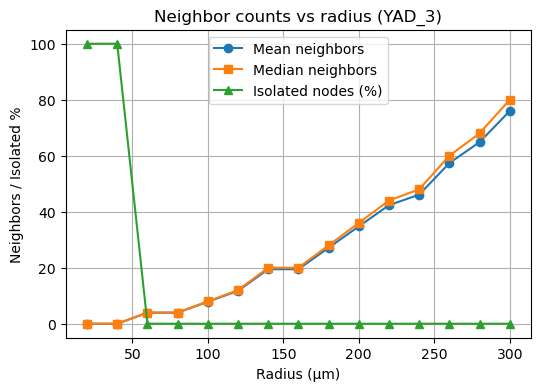

MSI samples:  44%|████▍     | 7/16 [00:05<00:07,  1.23it/s]


=== Neighbor Diagnostic for YAD_4 ===
Radius = 110.0 µm
N nodes = 7591
Mean neighbors:   7.83
Median neighbors: 8.00
Isolated nodes:   0 (0.00%)


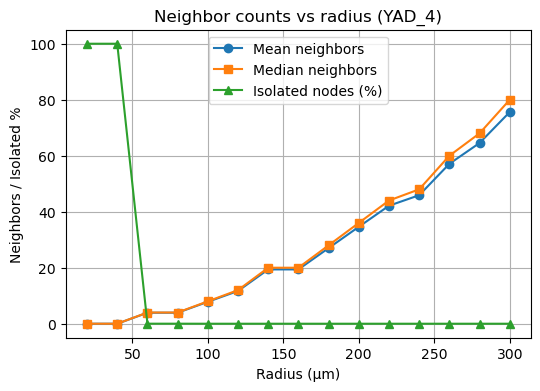

MSI samples:  50%|█████     | 8/16 [00:06<00:06,  1.21it/s]


=== Neighbor Diagnostic for AC_1 ===
Radius = 110.0 µm
N nodes = 6955
Mean neighbors:   7.83
Median neighbors: 8.00
Isolated nodes:   0 (0.00%)


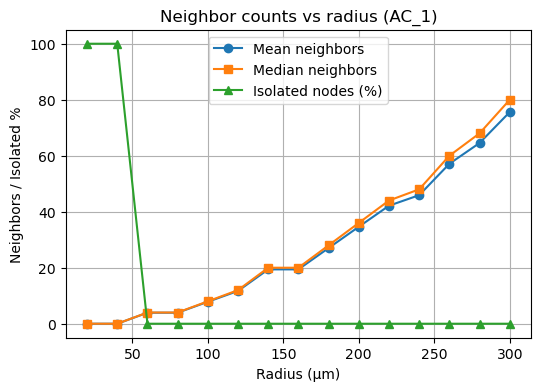

MSI samples:  56%|█████▋    | 9/16 [00:07<00:05,  1.23it/s]


=== Neighbor Diagnostic for AC_2 ===
Radius = 110.0 µm
N nodes = 5729
Mean neighbors:   7.81
Median neighbors: 8.00
Isolated nodes:   0 (0.00%)


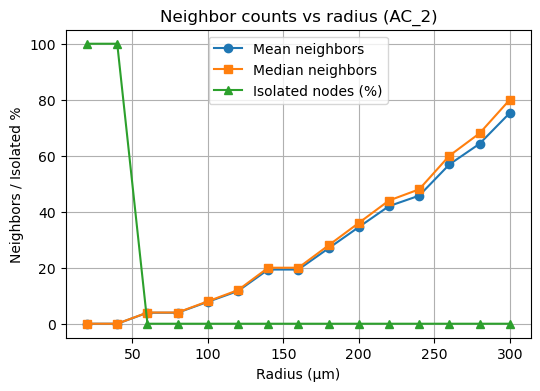

MSI samples:  62%|██████▎   | 10/16 [00:07<00:04,  1.29it/s]


=== Neighbor Diagnostic for AC_3 ===
Radius = 110.0 µm
N nodes = 7569
Mean neighbors:   7.84
Median neighbors: 8.00
Isolated nodes:   0 (0.00%)


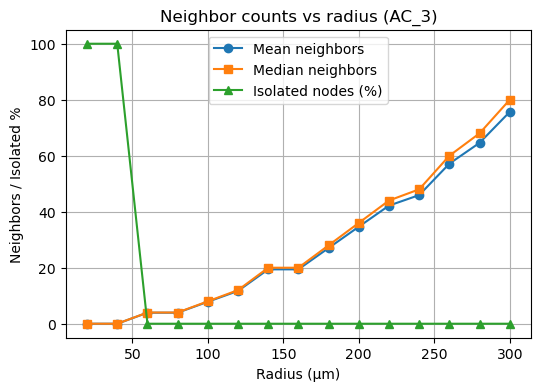

MSI samples:  69%|██████▉   | 11/16 [00:08<00:04,  1.18it/s]


=== Neighbor Diagnostic for AC_4 ===
Radius = 110.0 µm
N nodes = 7792
Mean neighbors:   7.83
Median neighbors: 8.00
Isolated nodes:   0 (0.00%)


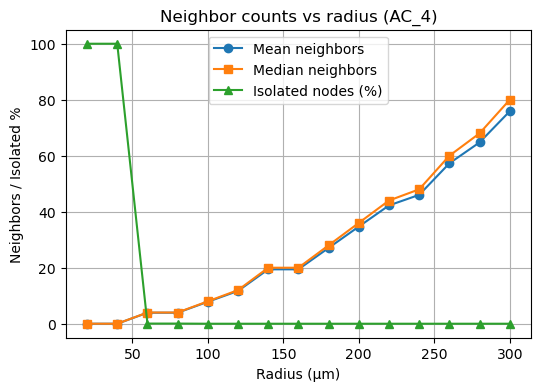

MSI samples:  75%|███████▌  | 12/16 [00:09<00:03,  1.17it/s]


=== Neighbor Diagnostic for AAD_1 ===
Radius = 110.0 µm
N nodes = 6471
Mean neighbors:   7.78
Median neighbors: 8.00
Isolated nodes:   2 (0.03%)


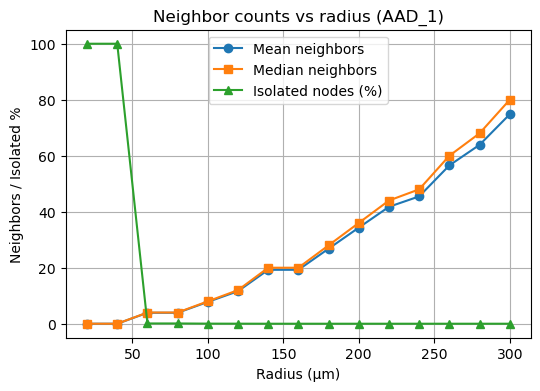

MSI samples:  81%|████████▏ | 13/16 [00:10<00:02,  1.22it/s]


=== Neighbor Diagnostic for AAD_2 ===
Radius = 110.0 µm
N nodes = 5959
Mean neighbors:   7.82
Median neighbors: 8.00
Isolated nodes:   0 (0.00%)


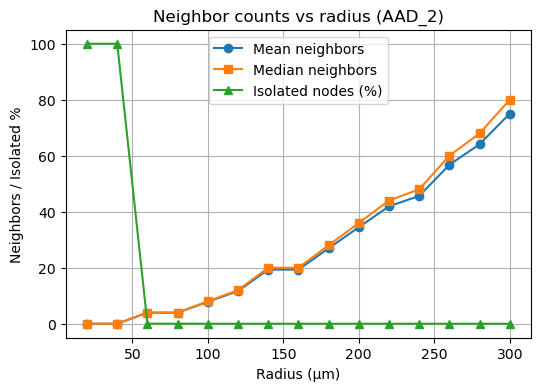

MSI samples:  88%|████████▊ | 14/16 [00:11<00:01,  1.28it/s]


=== Neighbor Diagnostic for AAD_3 ===
Radius = 110.0 µm
N nodes = 5392
Mean neighbors:   7.73
Median neighbors: 8.00
Isolated nodes:   1 (0.02%)


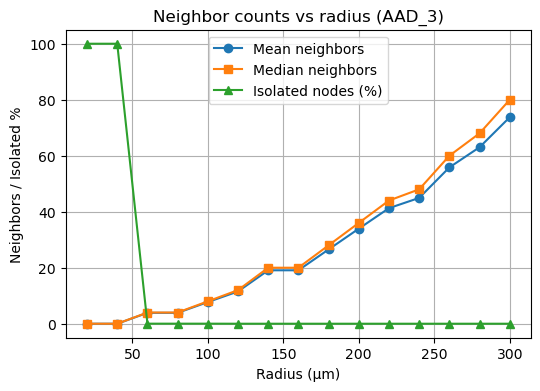

MSI samples:  94%|█████████▍| 15/16 [00:11<00:00,  1.36it/s]


=== Neighbor Diagnostic for AAD_4 ===
Radius = 110.0 µm
N nodes = 6833
Mean neighbors:   7.85
Median neighbors: 8.00
Isolated nodes:   0 (0.00%)


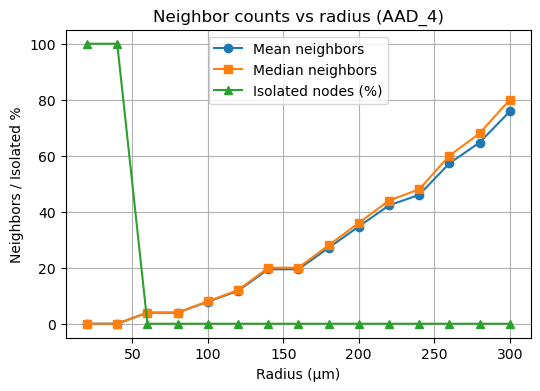

MSI samples: 100%|██████████| 16/16 [00:12<00:00,  1.26it/s]


In [39]:
# %% [markdown]
# ## 6. Run preprocessing for all samples

# %%
# MSI
for idx, fname in enumerate(tqdm(MSI_SAMPLE_FILES, desc="MSI samples")):
    sample_id = MSI_SAMPLE_IDS[idx]
    h5ad_path = os.path.join(MSI_INPUT_FOLDER, fname)
    if not os.path.exists(h5ad_path): continue
    data = process_msi_h5ad(h5ad_path, sample_id=sample_id)
    torch.save(data, os.path.join(OUTPUT_DIR, f"msi_{sample_id}.pt"))

Visium samples:   0%|          | 0/16 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



=== Neighbor Diagnostic for YC_1 ===
Radius = 110.0 µm
N nodes = 2112
Mean neighbors:   5.83
Median neighbors: 6.00
Isolated nodes:   0 (0.00%)


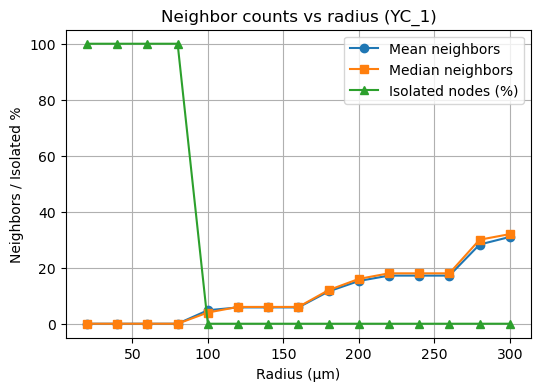

Visium samples:   6%|▋         | 1/16 [00:00<00:11,  1.32it/s]/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



=== Neighbor Diagnostic for YC_2 ===
Radius = 110.0 µm
N nodes = 2775
Mean neighbors:   5.85
Median neighbors: 6.00
Isolated nodes:   0 (0.00%)


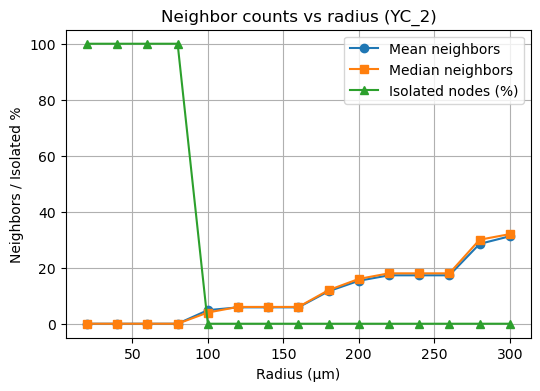

Visium samples:  12%|█▎        | 2/16 [00:01<00:11,  1.17it/s]/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



=== Neighbor Diagnostic for YC_3 ===
Radius = 110.0 µm
N nodes = 2808
Mean neighbors:   5.85
Median neighbors: 6.00
Isolated nodes:   0 (0.00%)


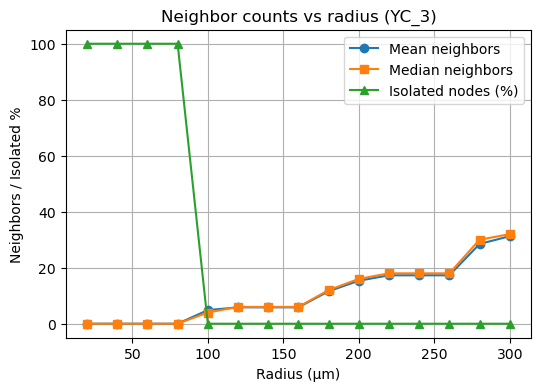

Visium samples:  19%|█▉        | 3/16 [00:02<00:12,  1.03it/s]/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



=== Neighbor Diagnostic for YC_4 ===
Radius = 110.0 µm
N nodes = 2725
Mean neighbors:   5.84
Median neighbors: 6.00
Isolated nodes:   0 (0.00%)


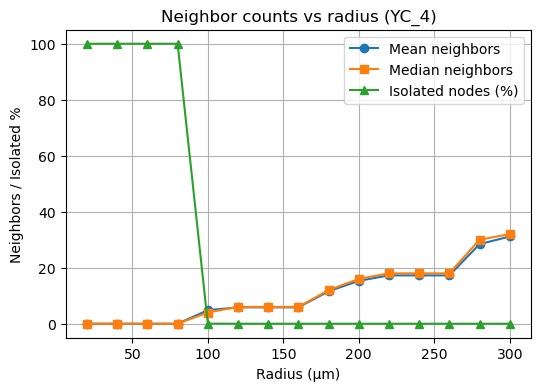

Visium samples:  25%|██▌       | 4/16 [00:03<00:11,  1.05it/s]/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



=== Neighbor Diagnostic for YAD_1 ===
Radius = 110.0 µm
N nodes = 2915
Mean neighbors:   5.86
Median neighbors: 6.00
Isolated nodes:   0 (0.00%)


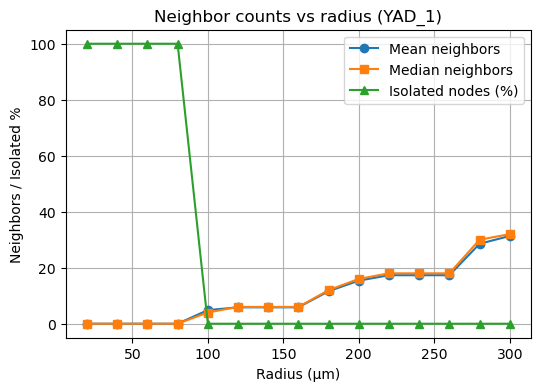

Visium samples:  31%|███▏      | 5/16 [00:04<00:10,  1.05it/s]/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



=== Neighbor Diagnostic for YAD_2 ===
Radius = 110.0 µm
N nodes = 2960
Mean neighbors:   5.85
Median neighbors: 6.00
Isolated nodes:   0 (0.00%)


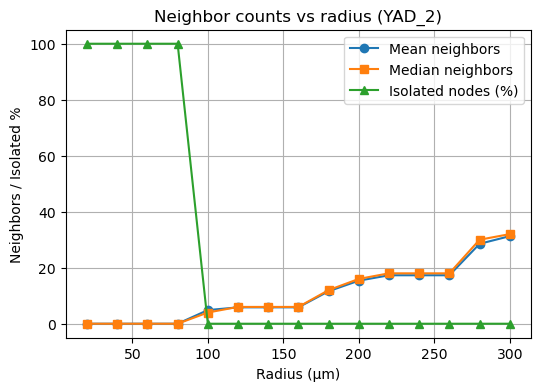

Visium samples:  38%|███▊      | 6/16 [00:05<00:09,  1.05it/s]/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



=== Neighbor Diagnostic for YAD_3 ===
Radius = 110.0 µm
N nodes = 2880
Mean neighbors:   5.85
Median neighbors: 6.00
Isolated nodes:   0 (0.00%)


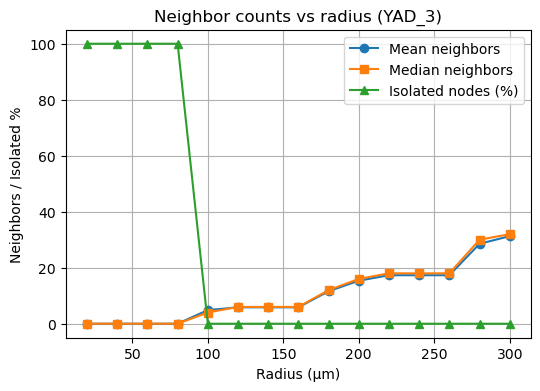

Visium samples:  44%|████▍     | 7/16 [00:06<00:08,  1.05it/s]/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



=== Neighbor Diagnostic for YAD_4 ===
Radius = 110.0 µm
N nodes = 2939
Mean neighbors:   5.85
Median neighbors: 6.00
Isolated nodes:   0 (0.00%)


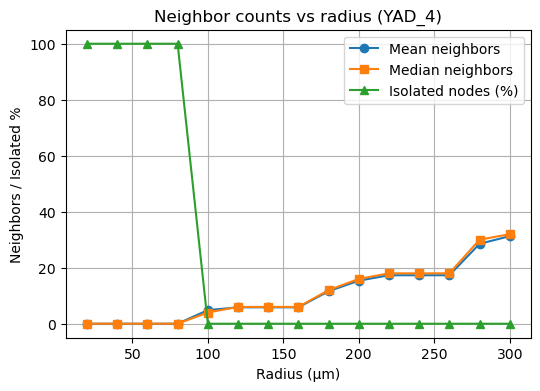

Visium samples:  50%|█████     | 8/16 [00:07<00:07,  1.04it/s]/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



=== Neighbor Diagnostic for AC_1 ===
Radius = 110.0 µm
N nodes = 3065
Mean neighbors:   5.84
Median neighbors: 6.00
Isolated nodes:   0 (0.00%)


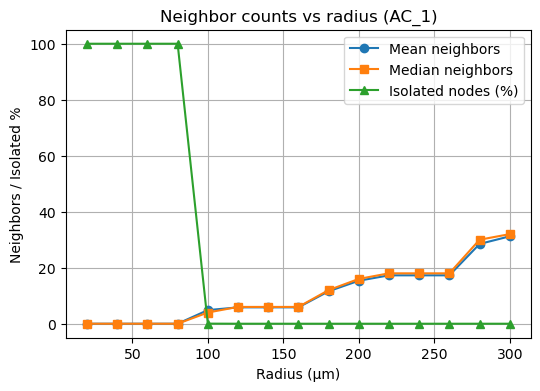

Visium samples:  56%|█████▋    | 9/16 [00:08<00:06,  1.03it/s]/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



=== Neighbor Diagnostic for AC_2 ===
Radius = 110.0 µm
N nodes = 3054
Mean neighbors:   5.86
Median neighbors: 6.00
Isolated nodes:   0 (0.00%)


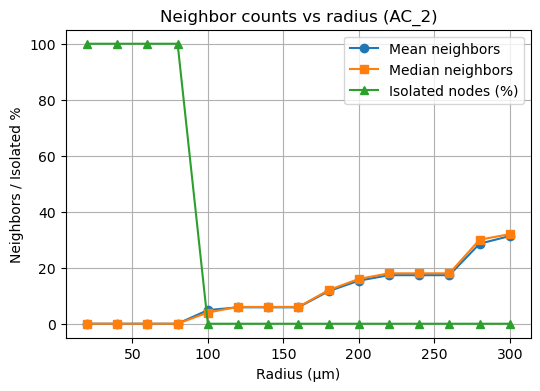

Visium samples:  62%|██████▎   | 10/16 [00:09<00:05,  1.03it/s]/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



=== Neighbor Diagnostic for AC_3 ===
Radius = 110.0 µm
N nodes = 2892
Mean neighbors:   5.85
Median neighbors: 6.00
Isolated nodes:   0 (0.00%)


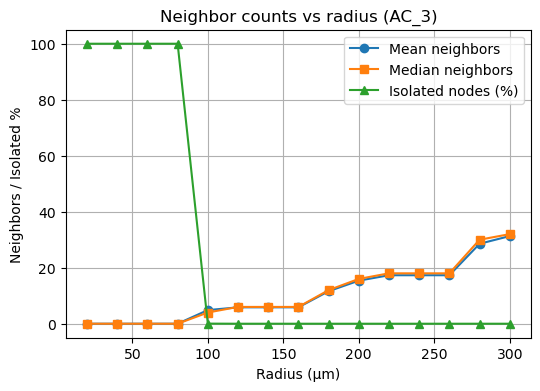

Visium samples:  69%|██████▉   | 11/16 [00:10<00:04,  1.03it/s]/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



=== Neighbor Diagnostic for AC_4 ===
Radius = 110.0 µm
N nodes = 3002
Mean neighbors:   5.86
Median neighbors: 6.00
Isolated nodes:   0 (0.00%)


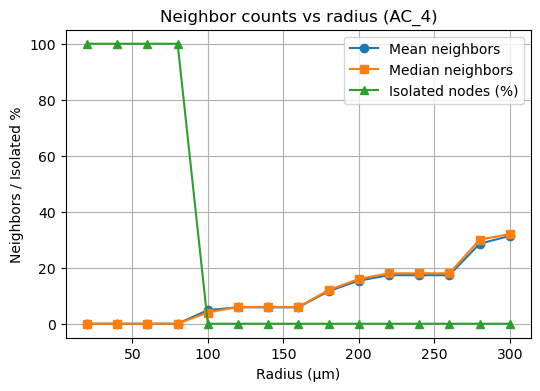

Visium samples:  75%|███████▌  | 12/16 [00:11<00:03,  1.03it/s]/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



=== Neighbor Diagnostic for AAD_1 ===
Radius = 110.0 µm
N nodes = 2700
Mean neighbors:   5.84
Median neighbors: 6.00
Isolated nodes:   0 (0.00%)


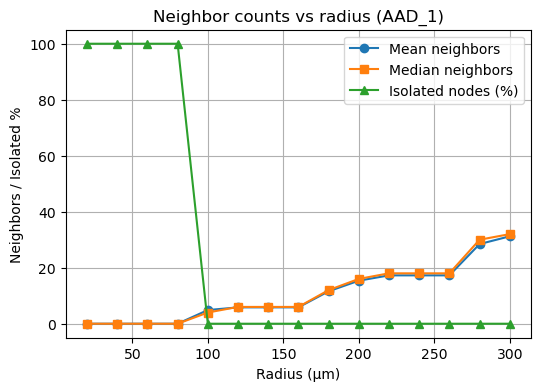

Visium samples:  81%|████████▏ | 13/16 [00:12<00:02,  1.06it/s]/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



=== Neighbor Diagnostic for AAD_2 ===
Radius = 110.0 µm
N nodes = 2171
Mean neighbors:   5.82
Median neighbors: 6.00
Isolated nodes:   0 (0.00%)


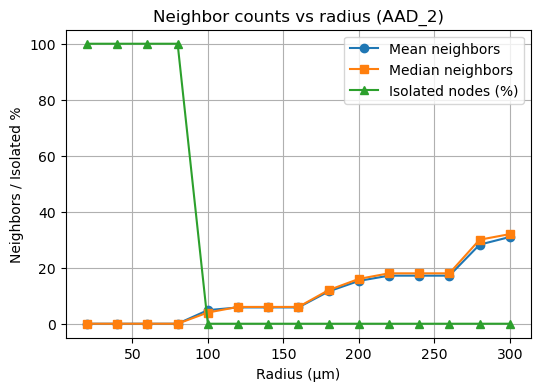

Visium samples:  88%|████████▊ | 14/16 [00:13<00:01,  1.12it/s]/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



=== Neighbor Diagnostic for AAD_3 ===
Radius = 110.0 µm
N nodes = 1584
Mean neighbors:   5.78
Median neighbors: 6.00
Isolated nodes:   0 (0.00%)


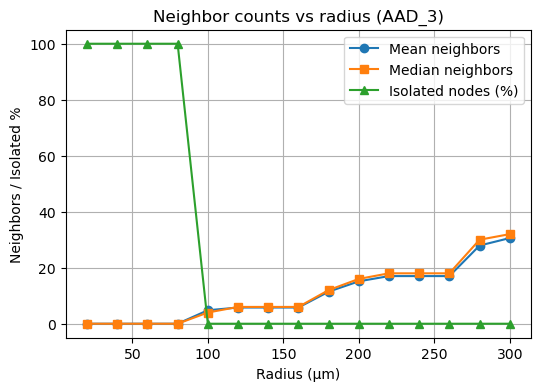

Visium samples:  94%|█████████▍| 15/16 [00:13<00:00,  1.23it/s]/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



=== Neighbor Diagnostic for AAD_4 ===
Radius = 110.0 µm
N nodes = 2438
Mean neighbors:   5.83
Median neighbors: 6.00
Isolated nodes:   0 (0.00%)


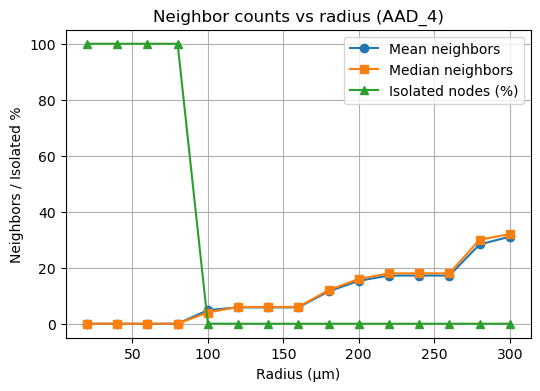

Visium samples: 100%|██████████| 16/16 [00:14<00:00,  1.08it/s]


In [40]:
# Visium
tissue_pos_df = reconstruct_visium_coords_from_tissue_positions(RNA_TISSUE_POSITIONS_CSV)
for idx, fname in enumerate(tqdm(RNA_SAMPLE_FILES, desc="Visium samples")):
    sample_id = RNA_SAMPLE_IDS[idx]
    h5ad_path = os.path.join(RNA_INPUT_FOLDER, fname)
    if not os.path.exists(h5ad_path): continue
    data = process_visium_h5ad(h5ad_path, sample_id=sample_id, tissue_positions_df=tissue_pos_df)
    torch.save(data, os.path.join(OUTPUT_DIR, f"visium_{sample_id}.pt"))
